
  Dataset 1
  Number of nodes: 299
  Time range:      0.0s  to  2980.0s
  Min T:           72.0000 °F
  Max T:           79.8209 °F


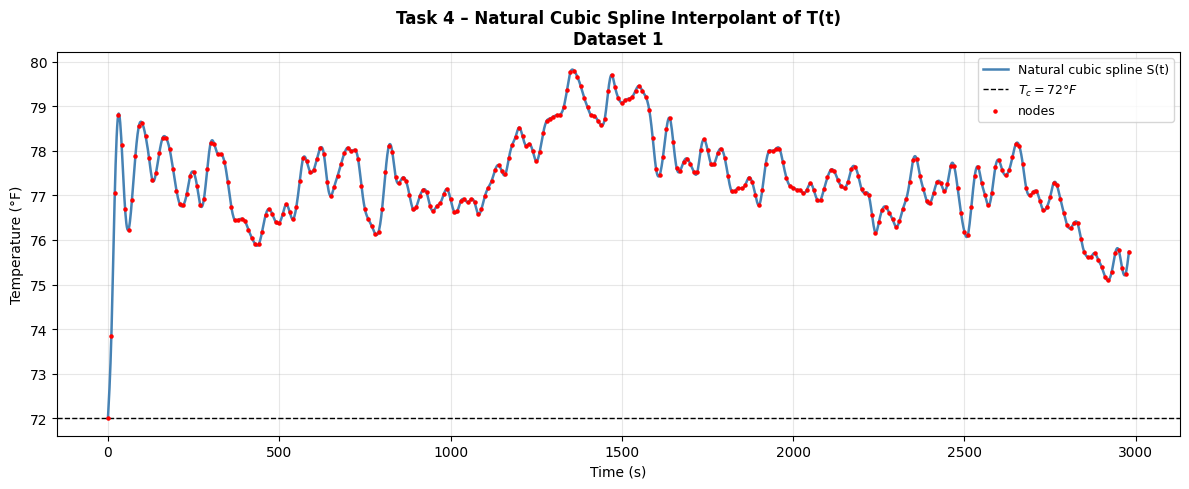


  Dataset 2
  Number of nodes: 299
  Time range:      0.0s  to  2980.0s
  Min T:           58.3525 °F
  Max T:           72.0000 °F


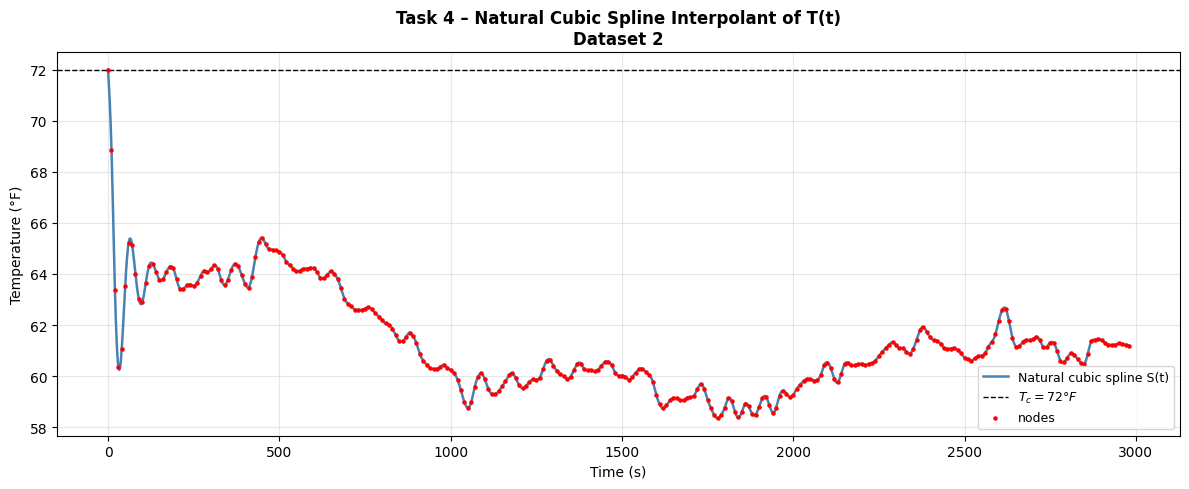


  Dataset 3
  Number of nodes: 299
  Time range:      0.0s  to  2980.0s
  Min T:           50.0155 °F
  Max T:           83.6336 °F


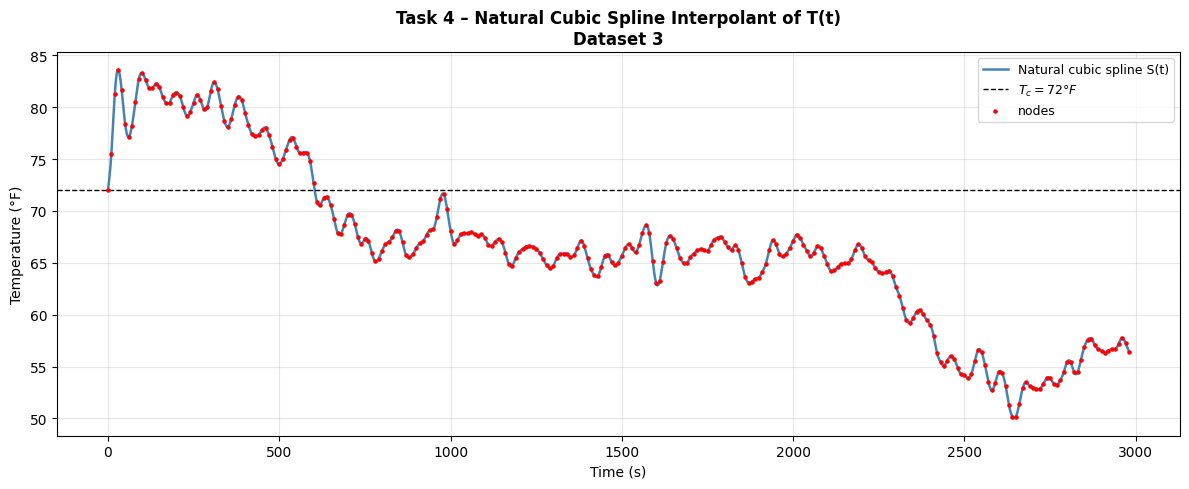

In [ ]:
#CUBIC SPLINE INTERPOLANT T (TASK 4, part c)

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import json
from pathlib import Path


def load_task3_definitions(notebook_path='task3.ipynb'):
    """Load Task 3 data and solver definitions without running its plots."""
    notebook = json.loads(Path(notebook_path).read_text(encoding='utf-8'))
    code = '\n'.join(
        ''.join(cell.get('source', []))
        for cell in notebook['cells']
        if cell.get('cell_type') == 'code'
    )
    code = code.split('\nfor theta_data, name in zip(datasets, dataset_names):')[0]
    namespace = {}
    exec(code, namespace)
    return namespace


_task3 = load_task3_definitions()
datasets      = _task3['datasets']
dataset_names = _task3['dataset_names']
solve_task3   = _task3['solve_task3']
alpha         = _task3['alpha']
k             = _task3['k']
dt_data       = _task3['dt_data']

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────

Tc = 72.0  # comfort threshold (°F)
h  = 1.0   # ODE step size


# ─────────────────────────────────────────────────────────────────────────────
# MAIN LOOP
# ─────────────────────────────────────────────────────────────────────────────

for theta_data, name in zip(datasets, dataset_names):
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    # ── Get T(t) from Task 3 ODE solver ──────────────────────────────────────
    t_solver, T_solver, _ = solve_task3(theta_data, h=h, alpha=alpha, k=k)

    step    = int(dt_data / h)
    t_nodes = t_solver[::step]
    T_nodes = T_solver[::step]
    t_fine  = np.linspace(t_nodes[0], t_nodes[-1], 2000)

    # ── Natural cubic spline ──────────────────────────────────────────────────
    cs = CubicSpline(t_nodes, T_nodes, bc_type='natural')
    P  = cs(t_fine)

    print(f"  Number of nodes: {len(t_nodes)}")
    print(f"  Time range:      {t_nodes[0]:.1f}s  to  {t_nodes[-1]:.1f}s")
    print(f"  Min T:           {np.min(P):.4f} °F")
    print(f"  Max T:           {np.max(P):.4f} °F")

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(t_fine, P, color='steelblue', lw=1.8, label='Natural cubic spline S(t)')
    ax.axhline(Tc, color='k', linestyle='--', lw=1, label=r'$T_c = 72°F$')
    ax.scatter(t_nodes, T_nodes, color='red', s=5, zorder=5, label='nodes')

    ax.set_title(f'Task 4 – Natural Cubic Spline Interpolant of T(t)\n{name}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Temperature (°F)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


  Dataset 1

  E = ∫₀ᵀ |T(t) - 72| dt  =  15978.9548 °F·s
  Crossings of Tc = 72°F:  0
    T(t) never crosses 72°F — always above comfort threshold


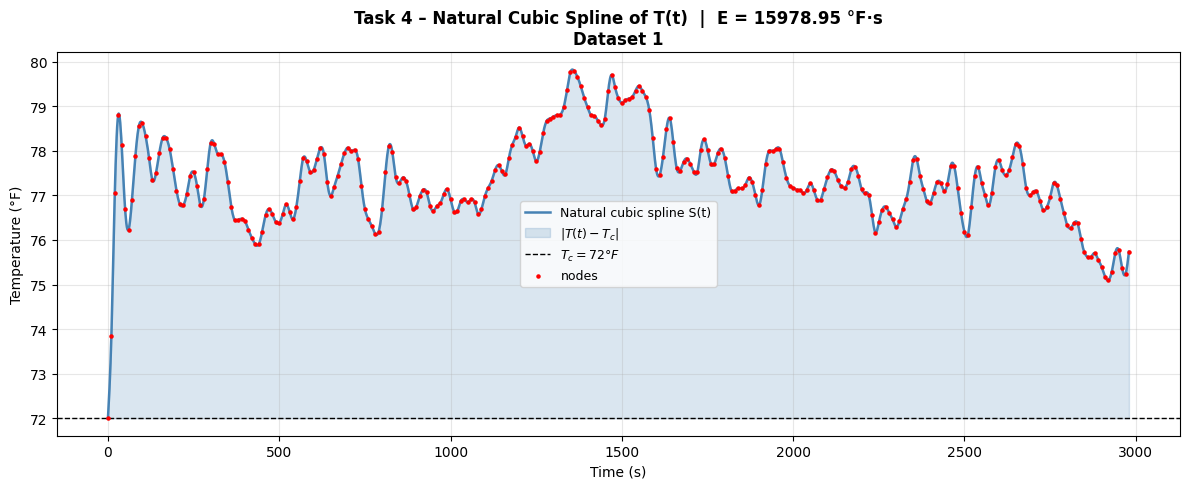


  Dataset 2

  E = ∫₀ᵀ |T(t) - 72| dt  =  31922.7733 °F·s
  Crossings of Tc = 72°F:  0
    T(t) never crosses 72°F — always above comfort threshold


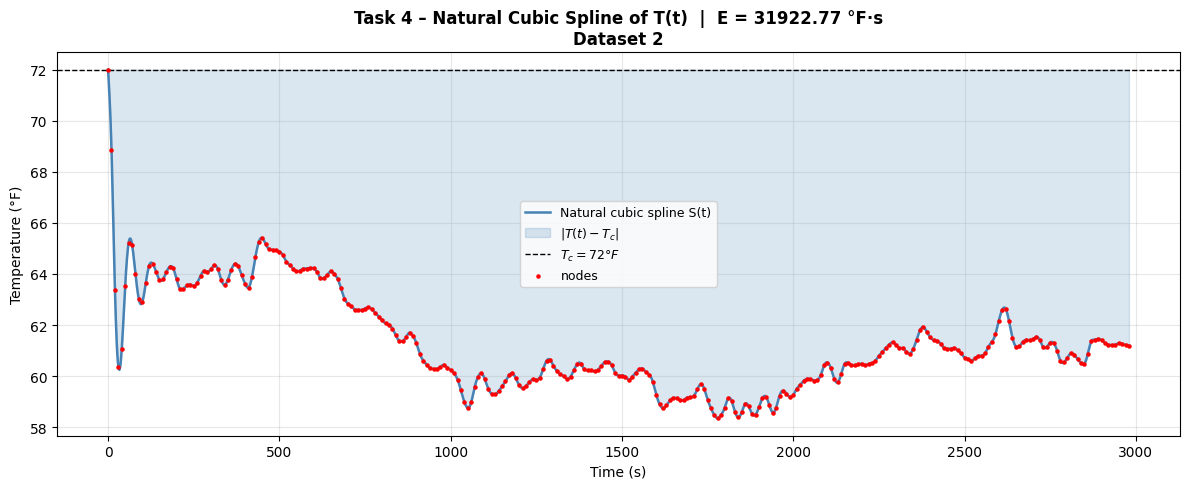


  Dataset 3

  E = ∫₀ᵀ |T(t) - 72| dt  =  24919.2681 °F·s
  Crossings of Tc = 72°F:  1
    at t = [603.32]


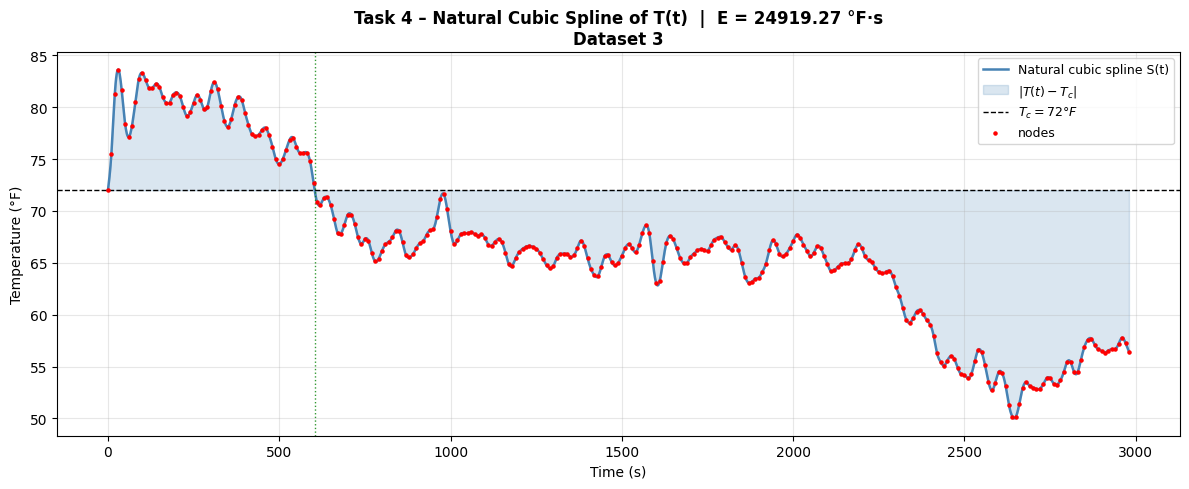

In [4]:
#INTEGRATION OF CUBIC POLYNOMIAL

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import json
from pathlib import Path


def load_task3_definitions(notebook_path='task3.ipynb'):
    """Load Task 3 data and solver definitions without running its plots."""
    notebook = json.loads(Path(notebook_path).read_text(encoding='utf-8'))
    code = '\n'.join(
        ''.join(cell.get('source', []))
        for cell in notebook['cells']
        if cell.get('cell_type') == 'code'
    )
    code = code.split('\nfor theta_data, name in zip(datasets, dataset_names):')[0]
    namespace = {}
    exec(code, namespace)
    return namespace


_task3 = load_task3_definitions()
datasets      = _task3['datasets']
dataset_names = _task3['dataset_names']
solve_task3   = _task3['solve_task3']
alpha         = _task3['alpha']
k             = _task3['k']
dt_data       = _task3['dt_data']

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────

Tc = 72.0  # comfort threshold (°F)
h  = 1.0   # ODE step size


def integrate_spline_exact(cs, t_start, t_end, Tc):
    """
    Analytically compute E = ∫_{t_start}^{t_end} |S(t) - Tc| dt.

    1. Shift spline down by Tc so roots = crossings of comfort threshold
    2. Find all crossings in [t_start, t_end]
    3. Split interval at crossings — sign of (S - Tc) is constant on each piece
    4. Integrate each piece using the antiderivative, take abs(), sum up
    """
    cs_shifted   = CubicSpline(cs.x, cs(cs.x) - Tc)
    all_roots    = cs_shifted.roots()
    roots        = all_roots[(all_roots > t_start) & (all_roots < t_end)]

    breakpoints  = np.sort(np.concatenate([[t_start], roots, [t_end]]))
    cs_antideriv = cs_shifted.antiderivative()

    E = 0.0
    for i in range(len(breakpoints) - 1):
        a, b = breakpoints[i], breakpoints[i + 1]
        E += abs(cs_antideriv(b) - cs_antideriv(a))

    return E, roots


# ─────────────────────────────────────────────────────────────────────────────
# MAIN LOOP
# ─────────────────────────────────────────────────────────────────────────────

for theta_data, name in zip(datasets, dataset_names):
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    # ── Get T(t) from Task 3 ODE solver ──────────────────────────────────────
    t_solver, T_solver, _ = solve_task3(theta_data, h=h, alpha=alpha, k=k)

    step    = int(dt_data / h)
    t_nodes = t_solver[::step]
    T_nodes = T_solver[::step]
    t_fine  = np.linspace(t_nodes[0], t_nodes[-1], 2000)

    # ── Natural cubic spline ──────────────────────────────────────────────────
    cs = CubicSpline(t_nodes, T_nodes, bc_type='natural')
    P  = cs(t_fine)

    # ── Analytical integration E = ∫₀ᵀ |T(t) - Tc| dt ───────────────────────
    E, roots = integrate_spline_exact(cs, t_nodes[0], t_nodes[-1], Tc)

    # ── Print results ─────────────────────────────────────────────────────────
    print(f"\n  E = ∫₀ᵀ |T(t) - 72| dt  =  {E:.4f} °F·s")
    print(f"  Crossings of Tc = 72°F:  {len(roots)}")
    if len(roots) > 0:
        print(f"    at t = {np.round(roots, 2)}")
    else:
        print(f"    T(t) never crosses 72°F — always above comfort threshold")

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(t_fine, P, color='steelblue', lw=1.8, label='Natural cubic spline S(t)')
    ax.fill_between(t_fine, Tc, P, alpha=0.2, color='steelblue', label=r'$|T(t) - T_c|$')
    ax.axhline(Tc, color='k', linestyle='--', lw=1, label=r'$T_c = 72°F$')
    ax.scatter(t_nodes, T_nodes, color='red', s=5, zorder=5, label='nodes')
    for r in roots:
        ax.axvline(r, color='green', linestyle=':', lw=1, alpha=0.8)

    ax.set_title(f'Task 4 – Natural Cubic Spline of T(t)  |  E = {E:.2f} °F·s\n{name}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Temperature (°F)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()